In [19]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [20]:
edges_df = pd.read_csv("enron_weighted_edges.csv")
# remove self-loops
edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

# Get the full network
G_full = (nx.from_pandas_edgelist
    (edges_df,
    source='Source',
    target='Target',
    edge_attr='Weight',
    create_using=nx.DiGraph()))
print(f"Enron dataset: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

Enron dataset: 56595 nodes, 226837 edges


In [21]:
# get subgraph of active user with degree >= 10
nodes_to_keep = [node for node, degree in G_full.degree() if degree >= 10]
G = G_full.subgraph(nodes_to_keep).copy()

print(f"Filtered Graph (Degree >= 10): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Filtered Graph (Degree >= 10): 6347 nodes, 140501 edges


In [22]:
density_full = nx.density(G_full)
density_filtered = nx.density(G)

print(f"Directed density (G_full): {density_full:.8f}")
print(f"Directed density (G, degree>=10): {density_filtered:.8f}")

Directed density (G_full): 0.00007082
Directed density (G, degree>=10): 0.00348828


In [23]:
# Weighted density for directed graph:

def weighted_density_directed(graph, weight_key='Weight'):
    n = graph.number_of_nodes()
    if n < 2:
        return 0.0

    total_possible_directed_edges = n * (n - 1)
    total_weight = sum(float(data.get(weight_key, 0.0)) for _, _, data in graph.edges(data=True))
    return total_weight / total_possible_directed_edges


wd_full = weighted_density_directed(G_full)
wd_filtered = weighted_density_directed(G)

print(f"Weighted density (G_full): {wd_full:.8f}")
print(f"Weighted density (G, degree>=10): {wd_filtered:.8f}")

Weighted density (G_full): 0.00030214
Weighted density (G, degree>=10): 0.01878353


Average In-Degree: 22.14
Average Out-Degree: 22.14


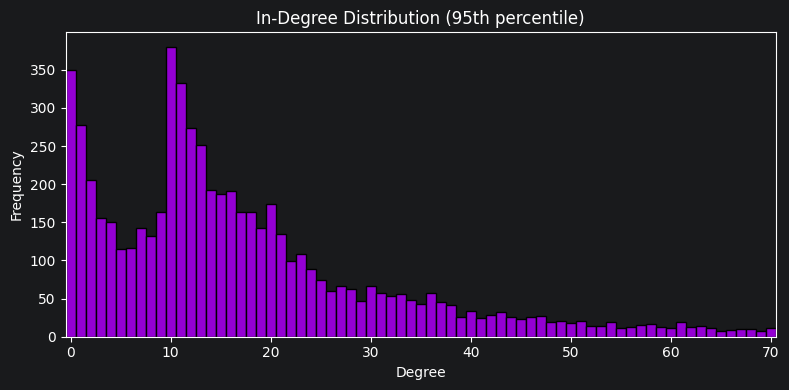

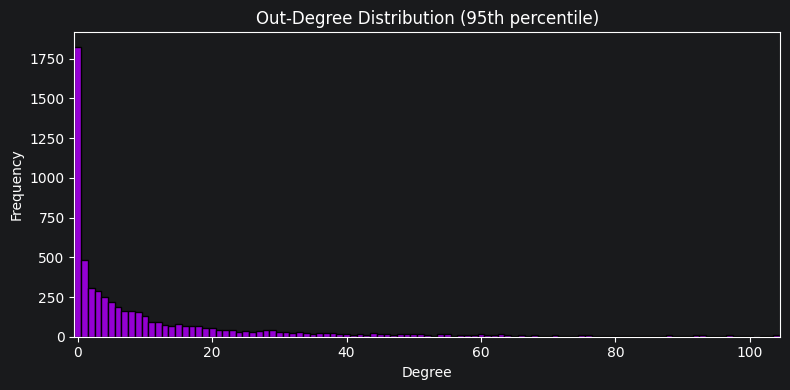

In [24]:
# In-degree and Out-degree distributions
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

avg_in_degree = np.mean(in_degrees)
avg_out_degree = np.mean(out_degrees)

print(f"Average In-Degree: {avg_in_degree:.2f}")
print(f"Average Out-Degree: {avg_out_degree:.2f}")

def plot_dist(data, title, pct=0.99):
    data = np.array(data)
    if len(data) == 0:
        return

    x_max = int(np.ceil(np.quantile(data, pct)))
    x_max = max(x_max, int(data.min()) + 1)

    plt.figure(figsize=(8, 4))
    bins = np.arange(data.min(), x_max + 2) - 0.5
    plt.hist(data, bins=bins, color='darkviolet', edgecolor='black')
    plt.xlim(data.min() - 0.5, x_max + 0.5)
    plt.title(title + f" ({int(pct*100)}th percentile)")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_dist(in_degrees, "In-Degree Distribution", pct=0.95)
plot_dist(out_degrees, "Out-Degree Distribution", pct=0.95)

In [25]:
# Average Clustering Coefficient
avg_clustering = nx.average_clustering(G)
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

Average Clustering Coefficient: 0.2863


In [26]:
# Betweenness Centrality
for u, v, d in G.edges(data=True):
    d['distance'] = 1.0 / d['Weight']

# Calculate betweenness using 'distance' instead of 'Weight'
betweenness = nx.betweenness_centrality(G,  weight='distance')
# Closeness Centrality
closeness = nx.closeness_centrality(G, distance='distance')

In [27]:
# Results
stats_df = pd.DataFrame({
    'Node_ID': list(betweenness.keys()),
    'Betweenness': list(betweenness.values()),
    'Closeness': list(closeness.values()),
    'In_Degree': [G.in_degree(n) for n in G.nodes()],
    'Out_Degree': [G.out_degree(n) for n in G.nodes()]
})

print("Top Influential Nodes by Betweenness:")
top = stats_df.sort_values(by='Betweenness', ascending=False).head(10).reset_index(drop=True)
print(top)

Top Influential Nodes by Betweenness:
   Node_ID  Betweenness  Closeness  In_Degree  Out_Degree
0      585     0.330705   1.318605        457         664
1     4377     0.147937   1.327707        471         541
2     5556     0.124642   1.301513        123         506
3     4404     0.112406   1.328444        439         445
4      802     0.092426   1.320695        170         198
5     3207     0.082051   1.333782        417         411
6    18646     0.081747   1.301561         32          45
7     4390     0.076750   1.321122        370         345
8      743     0.072563   1.316758        106         258
9     1070     0.071464   1.332264        291         413


In [28]:
mapping_df = pd.read_csv("id_mapping.csv")
full_stats_with_names = stats_df.merge(mapping_df, left_on='Node_ID', right_on='ID')
full_stats_with_names = full_stats_with_names.drop(columns=['ID'])
top_10_labeled = full_stats_with_names.sort_values(by='Betweenness', ascending=False).head(10).reset_index(drop=True)
print("--- Top 10 Enron Nodes by Betweenness ---")
print(top_10_labeled[['Email_Address', 'Node_ID', 'Betweenness', 'In_Degree', 'Out_Degree']])

--- Top 10 Enron Nodes by Betweenness ---
               Email_Address  Node_ID  Betweenness  In_Degree  Out_Degree
0    jeff.dasovich@enron.com      585     0.330705        457         664
1       tana.jones@enron.com     4377     0.147937        471         541
2      susan.scott@enron.com     5556     0.124642        123         506
3  sara.shackleton@enron.com     4404     0.112406        439         445
4    james.steffes@enron.com      802     0.092426        170         198
5      mark.taylor@enron.com     3207     0.082051        417         411
6  jeffery.fawcett@enron.com    18646     0.081747         32          45
7     gerald.nemec@enron.com     4390     0.076750        370         345
8  christi.nicolay@enron.com      743     0.072563        106         258
9   louise.kitchen@enron.com     1070     0.071464        291         413


In [29]:
full_stats_with_names['Total_Degree'] = full_stats_with_names['In_Degree'] + full_stats_with_names['Out_Degree']
top_10_total_degree = full_stats_with_names.sort_values(by='Total_Degree', ascending=False).head(10).reset_index(
    drop=True)

print("--- Top 10 Enron Nodes by Total Degree ---")
print(top_10_total_degree[['Node_ID', 'Email_Address', 'Total_Degree', 'In_Degree', 'Out_Degree']])

--- Top 10 Enron Nodes by Total Degree ---
   Node_ID               Email_Address  Total_Degree  In_Degree  Out_Degree
0     1219        sally.beck@enron.com          1163        301         862
1      585     jeff.dasovich@enron.com          1121        457         664
2     3266       kenneth.lay@enron.com          1120        339         781
3     4377        tana.jones@enron.com          1012        471         541
4      886     david.forster@enron.com          1006        159         847
5     4404   sara.shackleton@enron.com           884        439         445
6     3207       mark.taylor@enron.com           828        417         411
7     1700  technology.enron@enron.com           793          0         793
8     3631      outlook.team@enron.com           731         38         693
9     4390      gerald.nemec@enron.com           715        370         345


In [30]:
# Top 10 by Closeness Centrality
top_10_closeness = (
full_stats_with_names.sort_values(by='Closeness', ascending=False).head(10).reset_index(drop=True))

print("--- Top 10 Enron Nodes by Closeness ---")
print(top_10_closeness[['Email_Address', 'Node_ID', 'Closeness', 'In_Degree', 'Out_Degree']])

--- Top 10 Enron Nodes by Closeness ---
                Email_Address  Node_ID  Closeness  In_Degree  Out_Degree
0  william.bradford@enron.com      763   1.347040        145          44
1        tim.belden@enron.com      521   1.343953        239         163
2     john.lavorato@enron.com      998   1.343458        298         373
3      edward.sacks@enron.com      783   1.340803        106          73
4   lisa.mellencamp@enron.com     3190   1.334090        135          85
5       mark.taylor@enron.com     3207   1.333782        417         411
6    barry.tycholiz@enron.com     1406   1.333000        181         121
7    louise.kitchen@enron.com     1070   1.332264        291         413
8   elizabeth.sager@enron.com      609   1.331990        310         241
9     mark.haedicke@enron.com     1393   1.331069        251         296


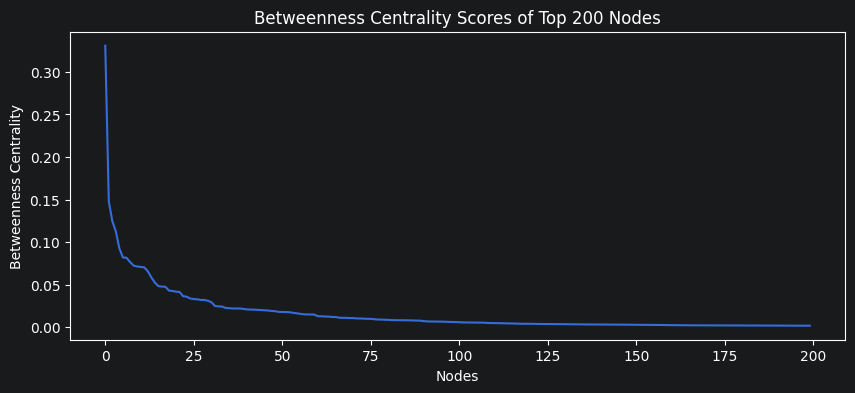

In [31]:
all_scores = sorted(stats_df['Betweenness'], reverse=True)
plt.figure(figsize=(10, 4))
plt.plot(all_scores[:200])
plt.title("Betweenness Centrality Scores of Top 200 Nodes")
plt.xlabel("Nodes")
plt.ylabel("Betweenness Centrality")
plt.show()

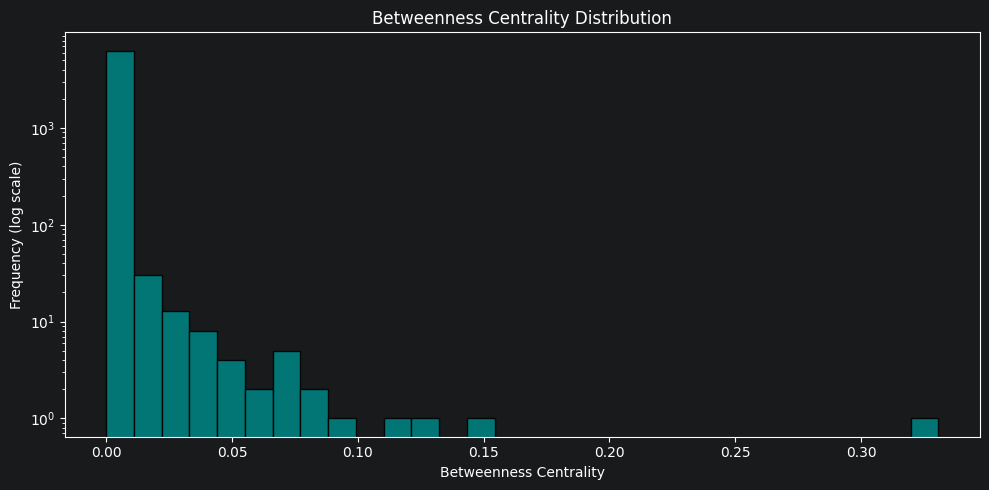

In [32]:
# Distribution of Betweenness Centrality
plt.figure(figsize=(10, 5))
plt.hist(stats_df['Betweenness'], bins=30, color='teal', edgecolor='black', alpha=0.9)
plt.yscale('log')
plt.title("Betweenness Centrality Distribution")
plt.xlabel("Betweenness Centrality")
plt.ylabel("Frequency (log scale)")
plt.tight_layout()
plt.show()

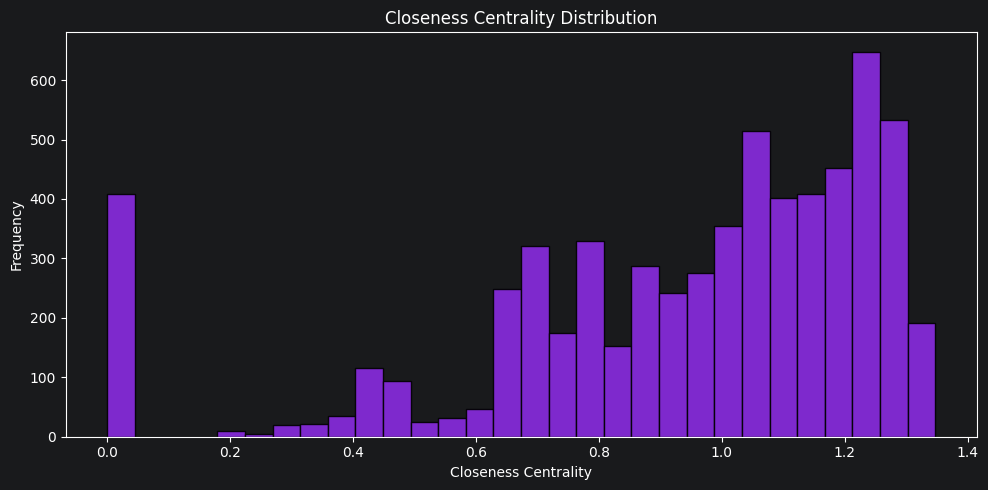

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(stats_df['Closeness'], bins=30, color='blueviolet', edgecolor='black', alpha=0.9)
plt.title("Closeness Centrality Distribution")
plt.xlabel("Closeness Centrality")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

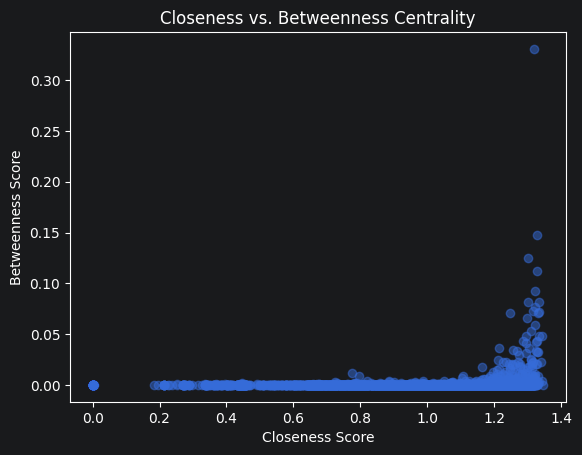

In [34]:
plt.scatter(stats_df['Closeness'], stats_df['Betweenness'], alpha=0.5)
plt.title("Closeness vs. Betweenness Centrality")
plt.xlabel("Closeness Score")
plt.ylabel("Betweenness Score")
plt.show()